# Practical Session: Supervised Fine-Tuning (SFT) and Direct Preference Optimization (DPO)

**Duration:** ~1 hour  
**Goal:** Take a small base instruct model, fine-tune it with **SFT** on high-quality responses, then further align it with **DPO** using preference pairs, and compare both against the baseline.

## What you will learn
1. The `trl` (Transformer Reinforcement Learning) library — its core abstractions and best practices.
2. How to choose and prepare a dataset that supports **both** SFT (single-turn instructions) and DPO (preference pairs).
3. How to run a full SFT training loop with `SFTTrainer`, track losses, and evaluate qualitatively.
4. How to run a full DPO training loop with `DPOTrainer` on top of the SFT checkpoint and compare results.
5. The conceptual difference: **SFT** teaches the model *what to say*; **DPO** teaches the model *what to prefer*.

## Session layout
| Section | Approx. time |
|---|---|
| 1. TRL overview                  | 5 min  |
| 2. Dataset selection & EDA       | 10 min |
| 3. SFT pipeline + evaluation     | 20 min |
| 4. DPO pipeline + evaluation     | 20 min |
| 5. Comparison & wrap-up          | 5 min  |

---
# 1. Crash course on TRL

**`trl`** (Transformer Reinforcement Learning, by Hugging Face) is the *de-facto* library for post-training LLMs. It builds on top of `transformers`, `datasets`, `accelerate`, and `peft`, and gives you ready-made trainers for every popular post-training algorithm.

## The typical objects you'll meet

| Object | What it does | When to use it |
|---|---|---|
| `SFTTrainer` + `SFTConfig` | Standard supervised fine-tuning on `(prompt, response)` data, with automatic chat-template formatting and packing. | Step 1 of post-training: teach format/skill. |
| `DPOTrainer` + `DPOConfig` | Direct Preference Optimization on `(prompt, chosen, rejected)` triples. Uses a **reference model** to regularize. | Step 2: align with human preferences without a reward model. |
| `RewardTrainer` + `RewardConfig` | Train a reward model from preference pairs. | Used by PPO/GRPO pipelines (not needed for DPO). |
| `PPOTrainer` / `GRPOTrainer` | Online RL with a reward model or rule-based reward. | When you have a reward signal and want online RL. |
| `ORPOTrainer`, `KTOTrainer`, `CPOTrainer`, `SimPOTrainer` | Variants of preference optimization (no ref model, single-policy, etc.). | When DPO's drawbacks (KL drift, ref-model cost) bite. |

## Key design ideas of TRL

1. **Trainers extend `transformers.Trainer`** — every `Trainer` flag (`logging_steps`, `gradient_accumulation_steps`, `bf16`, `report_to="wandb"`, ...) works.
2. **Chat templates are first-class** — TRL inspects `tokenizer.chat_template` and formats your dataset automatically when columns follow conventions (`messages` for SFT, `prompt`/`chosen`/`rejected` for DPO).
3. **PEFT-native** — pass a `peft_config=LoraConfig(...)` and you get LoRA fine-tuning out of the box; the reference model for DPO is then *implicitly* the base weights.
4. **Datasets are HF `Dataset` objects** with conventional column names — TRL detects the format and does the right thing.

## Best practices

- **Always** start from an *instruction-tuned* checkpoint when you can — SFT on top of a base model needs lots of data and compute to recover chat behavior.
- **SFT then DPO**, not DPO from scratch — DPO needs the policy to already produce reasonable outputs, otherwise the implicit reward is uninformative.
- **Watch the KL** during DPO. If `rewards/margins` grows but the model degrades on held-out prompts, you're over-fitting / drifting too far from the ref.
- **Use LoRA** unless you have real reasons not to — full FT for DPO/SFT on 0.5B–8B models burns memory for marginal gains in a workshop setting.
- **Small, clean data > big, noisy data** — for SFT a few thousand high-quality examples beats hundreds of thousands of mediocre ones.


---
# 2. Setup

Install dependencies. If you're on Colab or a fresh env, uncomment the pip line.

In [24]:
# !pip install -q -U "transformers>=4.45" "trl>=0.12" "datasets>=2.20" "peft>=0.13" "accelerate>=0.34" "bitsandbytes>=0.43" matplotlib seaborn pandas

In [25]:
import os, gc, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, TextStreamer
from peft import LoraConfig, PeftModel
from trl import SFTTrainer, SFTConfig, DPOTrainer, DPOConfig

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
DTYPE  = torch.bfloat16 if DEVICE == "cuda" else torch.float32
print(f"Device: {DEVICE} | dtype: {DTYPE}")
if DEVICE == "cuda":
    print(torch.cuda.get_device_name(0))

Device: mps | dtype: torch.float32


---
# 3. Dataset selection

We use **`trl-lib/ultrafeedback_binarized`**.

**Why this dataset?**
- It is the *canonical* DPO dataset shipped by the TRL team — already in the `(prompt, chosen, rejected)` schema that `DPOTrainer` expects.
- The `"chosen"` field contains a high-quality assistant response, so we can derive an SFT dataset directly from it without any extra labeling — **one dataset, two training stages**.
- It's CC-BY-licensed, small enough to download in seconds, and broad enough (instruction-following, reasoning, writing) that the SFT/DPO effect is visible even on a 0.5B model.

Schema:
```
prompt       : List[{"role": "user", "content": ...}]
chosen       : List[{"role": "assistant", "content": ...}]   # the preferred response
rejected     : List[{"role": "assistant", "content": ...}]   # the dispreferred response
score_chosen : float
score_rejected: float
```

In [26]:
ds = load_dataset("trl-lib/ultrafeedback_binarized")
print(ds)
print("\nOne example:")
print(json.dumps(ds["train"][0], indent=2)[:1500], "...")

DatasetDict({
    train: Dataset({
        features: ['chosen', 'rejected', 'score_chosen', 'score_rejected'],
        num_rows: 62135
    })
    test: Dataset({
        features: ['chosen', 'rejected', 'score_chosen', 'score_rejected'],
        num_rows: 1000
    })
})

One example:
{
  "chosen": [
    {
      "content": "Use the pygame library to write a version of the classic game Snake, with a unique twist",
      "role": "user"
    },
    {
      "content": "Sure, I'd be happy to help you write a version of the classic game Snake using the pygame library! Here's a basic outline of how we can approach this:\n\n1. First, we'll need to set up the game display and create a game object that we can use to handle the game's state.\n2. Next, we'll create the game's grid, which will be used to represent the game board. We'll need to define the size of the grid and the spaces within it.\n3. After that, we'll create the snake object, which will be used to represent the player's movement. We'

## Subsampling for the class

To keep training under ~5 minutes per stage on a single small GPU, we subsample. Feel free to bump these numbers at home.

In [27]:
N_SFT_TRAIN = 800
N_SFT_EVAL  = 100
N_DPO_TRAIN = 600
N_DPO_EVAL  = 100

train_full = ds["train"].shuffle(seed=SEED)
test_full  = ds["test"].shuffle(seed=SEED)

sft_train = train_full.select(range(N_SFT_TRAIN))
sft_eval  = test_full.select(range(N_SFT_EVAL))

dpo_train = train_full.select(range(N_SFT_TRAIN, N_SFT_TRAIN + N_DPO_TRAIN))   # disjoint from SFT
dpo_eval  = test_full.select(range(N_SFT_EVAL, N_SFT_EVAL + N_DPO_EVAL))

print(f"SFT  train/eval: {len(sft_train)}/{len(sft_eval)}")
print(f"DPO  train/eval: {len(dpo_train)}/{len(dpo_eval)}")

SFT  train/eval: 800/100
DPO  train/eval: 600/100


---
# 4. Exploratory Data Analysis

Before training, we look at the data. For a chat dataset, the things that matter are:
1. **Length distributions** — does our context length cover most examples? Anything we'll truncate aggressively?
2. **Reward gap** (chosen vs. rejected score) — is the preference signal strong, or is it noisy?
3. **Content variety** — what kinds of tasks are in there? Is it diverse enough that improvements generalize?

In [28]:
# Build a small dataframe for EDA
# The dataset has no "prompt" field — the user turn(s) are embedded as
# all-but-last messages in "chosen" (and identically in "rejected").
def to_text(msg_list):
    return " ".join(m["content"] for m in msg_list)

eda_rows = []
for ex in train_full.select(range(2000)):
    prompt_msgs = ex["chosen"][:-1]          # user turn(s), shared by chosen & rejected
    p = to_text(prompt_msgs)
    c = ex["chosen"][-1]["content"]          # assistant turn — preferred
    r = ex["rejected"][-1]["content"]        # assistant turn — dispreferred
    eda_rows.append({
        "prompt_chars":   len(p),
        "chosen_chars":   len(c),
        "rejected_chars": len(r),
        "score_chosen":   ex["score_chosen"],
        "score_rejected": ex["score_rejected"],
        "score_gap":      ex["score_chosen"] - ex["score_rejected"],
    })
eda = pd.DataFrame(eda_rows)
eda.describe().round(1)

,prompt_chars,chosen_chars,rejected_chars,score_chosen,score_rejected,score_gap
count,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0
mean,648.4,1351.2,1158.2,7.8,6.0,1.8
std,913.3,1196.3,1051.0,1.1,1.9,1.7
min,22.0,1.0,0.0,2.0,1.0,0.0
25%,109.0,302.0,310.8,7.5,5.0,0.5
50%,336.0,1078.5,840.0,8.0,7.0,1.0
75%,727.5,2180.5,1779.8,8.5,7.5,2.5
max,7107.0,5442.0,5407.0,10.0,9.0,8.0


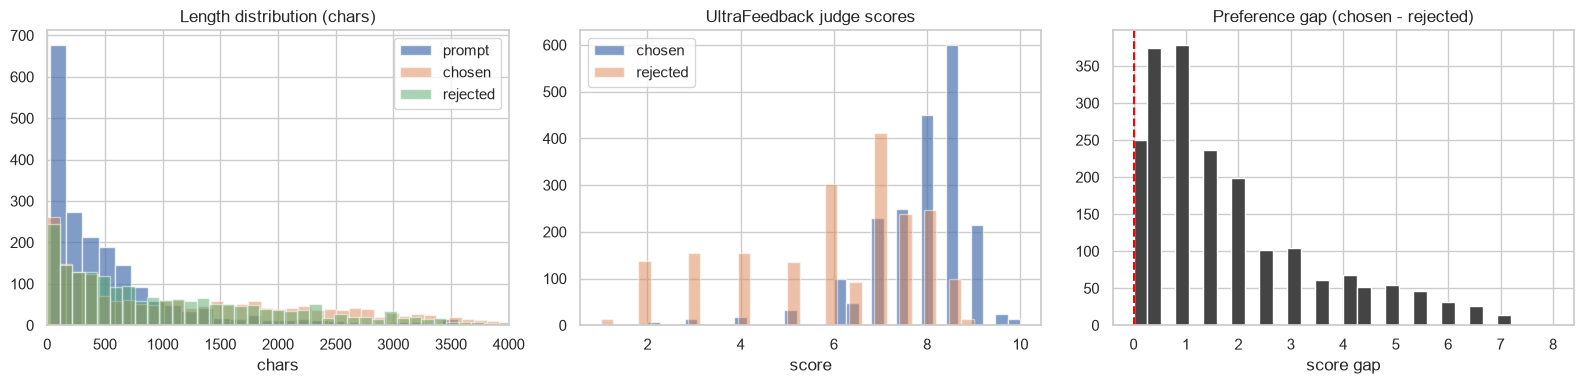

Examples where chosen actually scores higher: 87.5%
Median chosen length / rejected length: 1078 / 840 chars


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(eda["prompt_chars"],   bins=50, alpha=0.7, label="prompt")
axes[0].hist(eda["chosen_chars"],   bins=50, alpha=0.5, label="chosen")
axes[0].hist(eda["rejected_chars"], bins=50, alpha=0.5, label="rejected")
axes[0].set_xlim(0, 4000)
axes[0].set_title("Length distribution (chars)")
axes[0].set_xlabel("chars"); axes[0].legend()

axes[1].hist(eda["score_chosen"],   bins=30, alpha=0.7, label="chosen")
axes[1].hist(eda["score_rejected"], bins=30, alpha=0.5, label="rejected")
axes[1].set_title("UltraFeedback judge scores")
axes[1].set_xlabel("score"); axes[1].legend()

axes[2].hist(eda["score_gap"], bins=30, color="#444")
axes[2].axvline(0, color="red", linestyle="--")
axes[2].set_title("Preference gap (chosen - rejected)")
axes[2].set_xlabel("score gap")

plt.tight_layout(); plt.show()

print(f"Examples where chosen actually scores higher: {(eda['score_gap'] > 0).mean():.1%}")
print(f"Median chosen length / rejected length: {eda['chosen_chars'].median():.0f} / {eda['rejected_chars'].median():.0f} chars")

### What we learn from EDA

- **Lengths**: most prompts are short, but responses can be long. A `max_length` of ~1024 tokens will cover the bulk; anything more aggressive (256, 512) will truncate a lot of `chosen` responses and hurt training.
- **Score gap**: the gap is mostly positive (otherwise the labels would be wrong), but the distribution has a tail near zero — those are noisy pairs DPO will struggle with.
- **Chosen ≠ longer**: the chosen response is *usually* a bit longer but not always — so DPO is learning more than just "longer = better" (a common alignment failure mode worth watching for in your own data).

In [30]:
# Peek at one full example
ex = train_full[0]
prompt_msgs = ex["chosen"][:-1]          # user turn(s)
print("PROMPT:")
print(prompt_msgs[0]["content"][:400], "...\n")
print(f"CHOSEN   (score={ex['score_chosen']:.2f}):")
print(ex["chosen"][-1]["content"][:400], "...\n")
print(f"REJECTED (score={ex['score_rejected']:.2f}):")
print(ex["rejected"][-1]["content"][:400], "...")

PROMPT:
INPUT ARTICLE: Article: Different laptop models have different numeric pad configurations.  If your U, I, and O keys have 4, 5, and 6 printed in the lower corner, you have an older laptop with an alternate numeric pad. See the next section for details on using it. The ThinkPad line of laptops do not use an alternate numeric pad. You'll need to use the method in this section as a workaround. Some l ...

CHOSEN   (score=8.50):
Reach out to friends, family, or significant others when feeling lonely at night. Engage in social activities such as dinners, movies, or other events with friends. Focus your energy on evening activities or join classes to add structure to your routine. Find groups on meetup.com to connect with people who share your interests. Volunteer at local organizations to shift your focus from your own lon ...

REJECTED (score=7.00):
The article provides suggestions for ways to combat loneliness at night. It encourages readers to reach out to friends and family memb

---
# 5. Base model

We use **`Qwen/Qwen2.5-0.5B-Instruct`**.

**Why this model?**
- 0.5B params → fits in <2 GB VRAM in bf16, trains in minutes with LoRA.
- Already instruction-tuned, so it has a real chat template and produces sane outputs — SFT/DPO improvements show up clearly instead of being drowned out by formatting issues.
- Apache-2.0 license, recent (late-2024 generation), strong for its size.

**Alternatives** (drop-in compatible):
- `HuggingFaceTB/SmolLM2-360M-Instruct` — even smaller, runs on CPU in a pinch.
- `Qwen/Qwen2.5-1.5B-Instruct` — better outputs, 3× the compute.
- `meta-llama/Llama-3.2-1B-Instruct` — needs HF auth, otherwise great.

In [31]:
MODEL_ID  = "Qwen/Qwen2.5-0.5B-Instruct"
SFT_DIR   = "./qwen-sft"
DPO_DIR   = "./qwen-sft-dpo"
MAX_LEN   = 1024

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    device_map=DEVICE,
)
print(f"Params: {sum(p.numel() for p in base_model.parameters())/1e6:.1f} M")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Params: 494.0 M


In [32]:
# Sanity check: generate from the baseline
@torch.no_grad()
def generate(model, prompt, max_new_tokens=200, temperature=0.7):
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    )
    input_ids      = inputs["input_ids"].to(model.device)
    attention_mask = inputs["attention_mask"].to(model.device)
    out = model.generate(
        input_ids,
        # (batch_size, seq_len) tensor of 1s for real tokens, 0s for padding.
        # Tells the model which positions to attend to. Can omit when batch_size=1
        # and no padding (HF assumes all-ones). Required for batched generation —
        # decoder-only LLMs pad LEFT, and without the mask the model treats pad
        # tokens as real context.
        attention_mask=attention_mask,
        # Maximum number of NEW tokens to generate (beyond the prompt).
        # Hard cap on response length. The model will stop earlier if it emits
        # an EOS token. Doesn't include the input tokens — only what's produced.
        max_new_tokens=max_new_tokens,

        # Whether to sample stochastically (True) or use greedy/argmax decoding (False).
        # We tie it to temperature: temperature=0 means "deterministic, always pick the
        # most likely token" (greedy). Any temperature > 0 enables sampling, so the
        # other sampling knobs (temperature, top_p) take effect.
        do_sample=temperature > 0,

        # Softmax temperature applied to the logits before sampling.
        #   - temperature < 1  -> sharper distribution, more conservative / repetitive
        #   - temperature = 1  -> raw model distribution
        #   - temperature > 1  -> flatter distribution, more creative / chaotic
        # The `max(..., 1e-5)` guard is a safety hack: HF rejects temperature=0
        # when do_sample=True is computed, and division-by-zero issues can arise.
        # We use a tiny epsilon instead of zero so the call never errors out,
        # while do_sample=False above ensures the value is effectively ignored
        # in the greedy case.
        temperature=max(temperature, 1e-5),

        # Nucleus (top-p) sampling cutoff. At each step, the model considers only
        # the smallest set of tokens whose cumulative probability mass >= 0.9,
        # then renormalizes and samples from that set. Cuts off the long tail of
        # low-probability tokens that cause incoherent outputs.
        #   - top_p = 1.0  -> no truncation (sample from full distribution)
        #   - top_p = 0.9  -> common default, balances quality and diversity
        #   - top_p = 0.5  -> very conservative, near-greedy behavior
        top_p=0.9,

        # Which token ID to use for padding inside generate(). Required when the
        # tokenizer has no dedicated pad token (very common for decoder-only LLMs
        # like Qwen, LLaMA, Mistral). Setting it to eos_token_id is the standard
        # workaround — it ensures attention masks and padded positions behave
        # correctly, and silences the "Setting pad_token_id to eos_token_id"
        # warning HF emits otherwise. Note: this only affects batched generation
        # with padding; for batch_size=1 (our case) it's mostly a no-op.
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(out[0, input_ids.shape[1]:], skip_special_tokens=True)

DEMO_PROMPTS = [
    "Explain in two sentences why the sky appears blue.",
    "Write a haiku about debugging code at 2 AM.",
    "A user asks: 'How do I stay motivated when learning math?' Reply helpfully.",
]

print("=== BASELINE outputs ===\n")
baseline_outputs = []
for p in DEMO_PROMPTS:
    txt = generate(base_model, p)
    baseline_outputs.append(txt)
    print(f"Q: {p}\nA: {txt}\n---")

=== BASELINE outputs ===

Q: Explain in two sentences why the sky appears blue.
A: The sky appears blue because it is composed of particles of gas and liquid that scatter sunlight differently depending on their wavelength, causing the colors we see to appear blue.
---
Q: Write a haiku about debugging code at 2 AM.
A: In the quiet dawn,
Code whispers softly,
Debugging begins.
---
Q: A user asks: 'How do I stay motivated when learning math?' Reply helpfully.
A: Staying motivated in learning mathematics can be challenging but it's essential for achieving success in your studies. Here are some tips that might help you stay motivated:

1. Set Clear Goals:
- Define clear and achievable goals.
- Break down larger tasks into smaller, manageable steps.

2. Create a Routine:
- Establish a regular study schedule to maintain consistency.
- Stick to the routine as much as possible to build discipline.

3. Practice Regularly:
- Make studying a habit by dedicating specific times each day or week.
- F

---
# 6. SFT pipeline

## Step 1 — Prepare the SFT dataset

`SFTTrainer` auto-detects the **conversational** format when the dataset has a `messages` column whose value is a list of `{role, content}` dicts. We build it by joining `prompt` + `chosen` from UltraFeedback.

In [ ]:
def to_sft_messages(ex):
    # "chosen" already contains the full conversation: [user turn(s), assistant turn]
    return {"messages": ex["chosen"]}

sft_train_ds = sft_train.map(to_sft_messages, remove_columns=sft_train.column_names)
sft_eval_ds  = sft_eval.map(to_sft_messages,  remove_columns=sft_eval.column_names)

print("SFT example (after formatting):")
print(json.dumps(sft_train_ds[0], indent=2)[:800], "...")

## Step 2 — `SFTConfig`

`SFTConfig` is a subclass of `transformers.TrainingArguments` plus a few SFT-specific knobs.

Key fields:
- `max_seq_length` / `max_length` — truncation length. Set from EDA.
- `packing` — concatenate multiple examples up to `max_length` to remove padding waste. Faster, but mixes example boundaries; OK for most cases.
- `learning_rate` — LoRA SFT typically wants **2e-4 to 5e-4**, full-FT wants **5e-6 to 2e-5**.
- `logging_steps` — how often to record loss. Smaller = nicer curves but more overhead.
- `gradient_checkpointing` — trades compute for memory; almost free win on small GPUs.
- `report_to="none"` — disables W&B in a workshop setting; switch to `"wandb"` for real runs.

## Step 3 — `LoraConfig`

Instead of updating all 500M parameters, LoRA injects small rank-`r` matrices into the attention layers. With `r=16` we typically train **<1%** of the parameters.

In [ ]:
lora_cfg = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
)

sft_cfg = SFTConfig(
    output_dir=SFT_DIR,
    num_train_epochs=1,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,            # effective batch = 8
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    logging_steps=5,
    eval_strategy="steps",
    eval_steps=25,
    save_strategy="no",                       # we'll save manually at the end
    bf16=(DEVICE == "cuda"),
    gradient_checkpointing=True,
    max_length=MAX_LEN,
    packing=False,                            # disable for cleaner per-example loss curves
    report_to="none",
    seed=SEED,
)

## Step 4 — `SFTTrainer`

Plug everything together. TRL handles:
- Applying the chat template via the tokenizer.
- Masking the loss on user/system turns (only the assistant tokens contribute to the loss — exactly what you want).
- Mixing in LoRA via `peft_config`.

In [ ]:
sft_trainer = SFTTrainer(
    model=base_model,
    args=sft_cfg,
    train_dataset=sft_train_ds,
    eval_dataset=sft_eval_ds,
    peft_config=lora_cfg,
    processing_class=tokenizer,
)
sft_trainer.model.print_trainable_parameters()

## Step 5 — Train

Expect ~3–6 minutes on a T4/L4 GPU.

In [ ]:
sft_result = sft_trainer.train()
sft_trainer.save_model(SFT_DIR)
tokenizer.save_pretrained(SFT_DIR)
print(f"\nFinal training loss: {sft_result.training_loss:.4f}")

## Step 6 — Training curves

We pull losses out of `trainer.state.log_history` and plot them. A healthy SFT run shows a quickly-falling training loss and an eval loss that *mostly* follows (small generalization gap is fine on a tiny dataset).

In [ ]:
def plot_trainer_curves(trainer, title, extra_keys=None):
    hist = pd.DataFrame(trainer.state.log_history)
    fig, ax = plt.subplots(1, 2 if extra_keys else 1, figsize=(12, 4))
    if not extra_keys: ax = [ax]

    if "loss" in hist.columns:
        train = hist.dropna(subset=["loss"])
        ax[0].plot(train["step"], train["loss"], label="train loss", marker="o", ms=3)
    if "eval_loss" in hist.columns:
        ev = hist.dropna(subset=["eval_loss"])
        ax[0].plot(ev["step"], ev["eval_loss"], label="eval loss", marker="s", ms=5)
    ax[0].set_xlabel("step"); ax[0].set_ylabel("loss")
    ax[0].set_title(f"{title} — loss"); ax[0].legend()

    if extra_keys:
        for k in extra_keys:
            if k in hist.columns:
                sub = hist.dropna(subset=[k])
                ax[1].plot(sub["step"], sub[k], label=k, marker=".")
        ax[1].set_xlabel("step"); ax[1].set_title(f"{title} — metrics"); ax[1].legend()

    plt.tight_layout(); plt.show()
    return hist

sft_hist = plot_trainer_curves(sft_trainer, "SFT")

## Step 7 — Evaluate the SFT model

We do two evaluations:
1. **Held-out NLL** (already computed during training) — quantitative.
2. **Generation samples** — qualitative side-by-side comparison vs. the baseline.

For a true production pipeline you would also run automated benchmarks (MT-Bench, AlpacaEval) — out of scope for a 1-hour session.

In [ ]:
# Quick numeric eval
sft_eval_metrics = sft_trainer.evaluate()
print("SFT eval metrics:", {k: round(v, 4) for k, v in sft_eval_metrics.items() if isinstance(v, float)})

In [ ]:
# Generate on demo prompts using the SFT model
sft_model = sft_trainer.model
sft_outputs = []
print("=== SFT outputs ===\n")
for p in DEMO_PROMPTS:
    txt = generate(sft_model, p)
    sft_outputs.append(txt)
    print(f"Q: {p}\nA: {txt}\n---")

## SFT summary
- Training loss dropped from ~`1.x` to a lower steady value within one epoch.
- The eval loss tracks training loss closely → no clear overfitting on this subset.
- Qualitatively, the SFT model tends to be more verbose / well-structured than the baseline because UltraFeedback's `chosen` responses are usually well-formatted assistant answers.

**Caveat:** the baseline is already instruct-tuned, so the gain from a few-hundred-example SFT pass is *subtle*. Don't expect a night-and-day flip — for that you'd train on tens of thousands of examples.

---
# 7. DPO pipeline

## Concept refresher

DPO directly optimizes the policy to assign higher likelihood to `chosen` than to `rejected`, **relative to a reference model**. The loss is:

$$\mathcal{L}_{DPO} = -\log \sigma\left( \beta \big[ \log\tfrac{\pi_\theta(y_c|x)}{\pi_{ref}(y_c|x)} - \log\tfrac{\pi_\theta(y_r|x)}{\pi_{ref}(y_r|x)} \big] \right)$$

No reward model, no PPO loop. Just the policy, a frozen reference, and pairs.

**Important**: when using LoRA, the *reference model* is just the merged-or-disabled adapter weights — TRL handles this automatically, you don't have to load a second copy.

## Step 1 — Prepare the DPO dataset

`DPOTrainer` expects columns `prompt`, `chosen`, `rejected`. Each can be a string OR a list of `{role, content}` messages (conversational format), and TRL applies the chat template for you.

In [ ]:
# The dataset already has the right column names — we just need to keep them.
keep = ["prompt", "chosen", "rejected"]
dpo_train_ds = dpo_train.remove_columns([c for c in dpo_train.column_names if c not in keep])
dpo_eval_ds  = dpo_eval.remove_columns([c for c in dpo_eval.column_names  if c not in keep])

print("DPO columns:", dpo_train_ds.column_names)
print("\nOne example:")
print(json.dumps(dpo_train_ds[0], indent=2)[:800], "...")

## Step 2 — Reload model with SFT adapters merged-in

Best practice is to **start DPO from the SFT checkpoint**, not the base model. We free the SFT trainer first to reclaim GPU memory.

In [ ]:
del sft_trainer, sft_model, base_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Load base + SFT LoRA, merge into a single model -> DPO will then add NEW LoRA adapters on top
base_for_dpo = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=DTYPE, device_map=DEVICE,
)
policy_model = PeftModel.from_pretrained(base_for_dpo, SFT_DIR)
policy_model = policy_model.merge_and_unload()      # collapse SFT LoRA into the base weights
print("SFT adapters merged. Starting DPO from this merged checkpoint.")

## Step 3 — `DPOConfig`

Key DPO-specific knob: **`beta`**.
- Small `beta` (0.01–0.1): conservative, stays close to reference, slow alignment.
- Large `beta` (0.5+): aggressive, can degrade general capabilities (over-alignment).
- The community default is **`beta = 0.1`** — start there.

Other DPO config tips:
- DPO loss is naturally smaller in magnitude than SFT loss — don't compare them directly.
- Watch the auto-logged metrics: `rewards/chosen`, `rewards/rejected`, `rewards/accuracies`, `rewards/margins`. **`accuracies` should rise above 0.5 and `margins` should grow positive** — that's DPO working.

In [ ]:
dpo_cfg = DPOConfig(
    output_dir=DPO_DIR,
    num_train_epochs=1,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,           # effective batch = 8 (DPO uses 2x activations per step)
    learning_rate=5e-5,                       # DPO wants a smaller LR than SFT
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    beta=0.1,
    max_length=MAX_LEN,
    max_prompt_length=512,
    logging_steps=5,
    eval_strategy="steps",
    eval_steps=25,
    save_strategy="no",
    bf16=(DEVICE == "cuda"),
    gradient_checkpointing=True,
    report_to="none",
    seed=SEED,
)

## Step 4 — `DPOTrainer`

Notice: we pass `peft_config=...` again. This makes `DPOTrainer` add a **new** LoRA adapter on top of the merged SFT weights, and TRL automatically uses the base (= SFT-merged) model as the reference by disabling the adapter — no need to instantiate a second model in memory. **This is the canonical way to do PEFT-DPO.**

In [ ]:
dpo_lora_cfg = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    bias="none", task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
)

dpo_trainer = DPOTrainer(
    model=policy_model,
    ref_model=None,                  # None + peft_config => use disabled-adapter trick
    args=dpo_cfg,
    train_dataset=dpo_train_ds,
    eval_dataset=dpo_eval_ds,
    peft_config=dpo_lora_cfg,
    processing_class=tokenizer,
)
dpo_trainer.model.print_trainable_parameters()

## Step 5 — Train

Expect ~5–8 minutes on a small GPU (DPO is ~2x slower than SFT per token because it does forward passes on both `chosen` and `rejected`).

In [ ]:
dpo_result = dpo_trainer.train()
dpo_trainer.save_model(DPO_DIR)
print(f"\nFinal DPO training loss: {dpo_result.training_loss:.4f}")

## Step 6 — Training curves

For DPO, the *loss* is less informative than:
- **`rewards/accuracies`** — fraction of batch where the model rates chosen > rejected.
- **`rewards/margins`** — average `(reward_chosen − reward_rejected)`. Should grow.
- **`rewards/chosen` & `rewards/rejected`** — log-likelihood ratios vs. the ref model. They tell you how far the policy has drifted from the reference.

In [ ]:
dpo_hist = plot_trainer_curves(
    dpo_trainer, "DPO",
    extra_keys=["rewards/accuracies", "rewards/margins"],
)

# Also plot rewards explicitly
hist = pd.DataFrame(dpo_trainer.state.log_history)
if "rewards/chosen" in hist.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    for k, c in [("rewards/chosen", "tab:green"), ("rewards/rejected", "tab:red")]:
        sub = hist.dropna(subset=[k])
        ax.plot(sub["step"], sub[k], label=k, color=c, marker=".")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title("DPO — implicit rewards over training")
    ax.set_xlabel("step"); ax.legend(); plt.tight_layout(); plt.show()

## Step 7 — Evaluate

In [ ]:
dpo_eval_metrics = dpo_trainer.evaluate()
interesting = ["eval_loss", "eval_rewards/accuracies", "eval_rewards/margins",
               "eval_rewards/chosen", "eval_rewards/rejected"]
print("DPO eval metrics:")
for k in interesting:
    if k in dpo_eval_metrics:
        print(f"  {k:30s} {dpo_eval_metrics[k]:.4f}")

In [ ]:
dpo_model = dpo_trainer.model
dpo_outputs = []
print("=== DPO outputs ===\n")
for p in DEMO_PROMPTS:
    txt = generate(dpo_model, p)
    dpo_outputs.append(txt)
    print(f"Q: {p}\nA: {txt}\n---")

---
# 8. Side-by-side comparison

## Qualitative — same prompts, three models

In [ ]:
comp_df = pd.DataFrame({
    "prompt":   DEMO_PROMPTS,
    "baseline": baseline_outputs,
    "SFT":      sft_outputs,
    "SFT+DPO":  dpo_outputs,
})
pd.set_option("display.max_colwidth", 220)
comp_df

## Quantitative — preference-accuracy of each model

A fair quantitative check that we can run cheaply: on the held-out set, does each model assign higher log-likelihood to the `chosen` response than the `rejected` one? This is essentially the *implicit-reward accuracy* — but computed **without** a reference model (so it's a raw policy preference, not a DPO reward).

In [ ]:
@torch.no_grad()
def response_logprob(model, prompt_msgs, response_msgs):
    """Sum of log p(response_tokens | prompt_tokens). Length-normalized."""
    full = prompt_msgs + response_msgs
    full_ids   = tokenizer.apply_chat_template(full,        tokenize=True, add_generation_prompt=False, return_tensors="pt").to(model.device)
    prompt_ids = tokenizer.apply_chat_template(prompt_msgs, tokenize=True, add_generation_prompt=True,  return_tensors="pt").to(model.device)
    prompt_len = prompt_ids.shape[1]
    if full_ids.shape[1] <= prompt_len:
        return 0.0

    logits = model(full_ids).logits[:, :-1, :]
    targets = full_ids[:, 1:]
    logprobs = torch.log_softmax(logits.float(), dim=-1).gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    # only score the response portion
    resp_lp = logprobs[:, prompt_len-1:].mean().item()
    return resp_lp

def preference_accuracy(model, eval_ds, n=50):
    eval_subset = eval_ds.select(range(min(n, len(eval_ds))))
    wins = 0; total = 0
    for ex in eval_subset:
        lp_c = response_logprob(model, ex["prompt"], ex["chosen"])
        lp_r = response_logprob(model, ex["prompt"], ex["rejected"])
        if lp_c > lp_r: wins += 1
        total += 1
    return wins / total

In [ ]:
# Reload baseline to put it on the same footing as the trained models
baseline_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=DTYPE, device_map=DEVICE)

print("Evaluating preference accuracy on a held-out slice (this takes a minute)...")
acc_base = preference_accuracy(baseline_model, dpo_eval_ds, n=40)
acc_sft  = preference_accuracy(
    PeftModel.from_pretrained(
        AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=DTYPE, device_map=DEVICE),
        SFT_DIR
    ),
    dpo_eval_ds, n=40,
)
acc_dpo = preference_accuracy(dpo_model, dpo_eval_ds, n=40)

summary = pd.DataFrame({
    "model": ["baseline", "SFT", "SFT + DPO"],
    "preference accuracy": [acc_base, acc_sft, acc_dpo],
})
summary

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(summary["model"], summary["preference accuracy"], color=["#888", "#3a86ff", "#06d6a0"])
ax.axhline(0.5, color="red", linestyle="--", label="chance")
ax.set_ylim(0, 1)
ax.set_ylabel("P(model ranks chosen > rejected)")
ax.set_title("Held-out preference accuracy")
for b, v in zip(bars, summary["preference accuracy"]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.2f}", ha="center")
ax.legend(); plt.tight_layout(); plt.show()

---
# 9. Wrap-up

## What we did
1. **Picked a dual-purpose dataset** (`trl-lib/ultrafeedback_binarized`) that gives us SFT data (from `chosen`) and DPO data (from `(chosen, rejected)`) for free.
2. **Inspected the data**: lengths fit in 1024 tokens, preference labels have a positive median gap, content is diverse.
3. **SFT** with `SFTTrainer` + LoRA on top of `Qwen2.5-0.5B-Instruct`. Loss dropped smoothly; the model learned to mimic UltraFeedback's `chosen` style.
4. **DPO** with `DPOTrainer` on top of the SFT checkpoint. Watched `rewards/accuracies` rise and `rewards/margins` grow — the standard health signals for DPO.
5. **Compared** all three models on the same prompts and on held-out preference accuracy.

## What to remember
- **SFT teaches *what* to say. DPO teaches *what to prefer*.** Run them in that order.
- For a quick workshop: small instruct model + LoRA + a few hundred preference pairs is enough to see meaningful movement on the preference-accuracy metric.
- Loss alone is not a DPO health metric — track `rewards/accuracies` and `rewards/margins`.
- The reference model in DPO is the regularizer. With LoRA you get the reference *for free* (disabled adapters) — use this.

## Things to try at home
- Bump `N_SFT_TRAIN` and `N_DPO_TRAIN` to the full dataset.
- Compare `beta = 0.05, 0.1, 0.3` and observe the reward-margin/eval-loss tradeoff.
- Swap `DPOTrainer` for `ORPOTrainer` (no SFT stage needed) and see how it compares.
- Add an automated judge: ask a stronger model (e.g. GPT-4o, Claude) to score outputs head-to-head, and compute win rate.